In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

sns.set_theme(style='whitegrid')
os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)
print('Ready')

Ready


In [2]:
# Load processed data
X_test = np.load('../data/processed/X_test.npy')
y_test = np.load('../data/processed/y_test.npy')
print(f'Test set loaded: {X_test.shape[0]:,} samples')

Test set loaded: 183,424 samples


In [3]:
# Rule-based baseline
# Flag everything as attack — worst case IDS
baseline_predictions = np.ones(len(y_test), dtype=int)

# Calculate metrics
cm = confusion_matrix(y_test, baseline_predictions)
TN, FP, FN, TP = cm.ravel()

fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
accuracy = (TP + TN) / len(y_test)

print('=== Baseline Results ===')
print(f'True Positives:   {TP:,}')
print(f'True Negatives:   {TN:,}')
print(f'False Positives:  {FP:,}  ← the problem')
print(f'False Negatives:  {FN:,}')
print(f'\nFalse Positive Rate: {fpr:.4f} ({fpr*100:.1f}%)')
print(f'Accuracy:            {accuracy:.4f} ({accuracy*100:.1f}%)')

=== Baseline Results ===
True Positives:   75,950
True Negatives:   0
False Positives:  107,474  ← the problem
False Negatives:  0

False Positive Rate: 1.0000 (100.0%)
Accuracy:            0.4141 (41.4%)


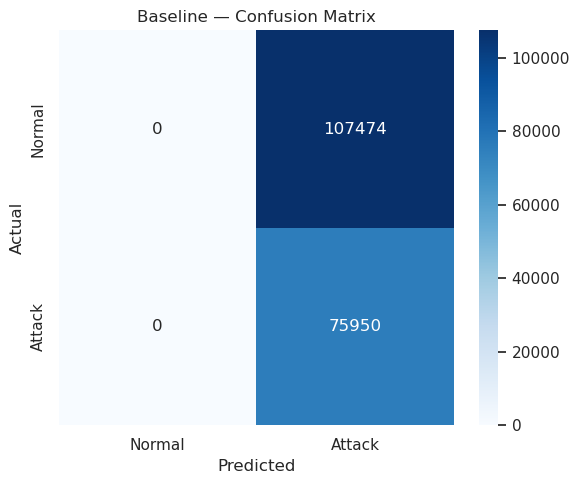

Saved


In [4]:
# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Baseline — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix_baseline.png', dpi=150)
plt.show()
print('Saved')

In [5]:
# Save baseline metrics
baseline_metrics = pd.DataFrame([{
    'Model': 'Baseline (Rule-Based)',
    'Accuracy': round(accuracy, 4),
    'False Positive Rate': round(fpr, 4),
    'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN
}])
baseline_metrics.to_csv('../results/metrics/results_summary.csv', index=False)
print('Baseline metrics saved')
print(baseline_metrics.to_string(index=False))

Baseline metrics saved
                Model  Accuracy  False Positive Rate    TP  TN     FP  FN
Baseline (Rule-Based)    0.4141                  1.0 75950   0 107474   0
